# Storage ($G'$) and Loss ($G''$) Moduli

We can calculate the storage and loss moduli on the smooth $G(t)$ using (https://pubs.acs.org/doi/10.1021/acs.macromol.3c01893?ref=pdf)


$$G^\prime(\omega) = \omega \int_0^\infty G(t)\sin(\omega t) dt$$

$$G^{\prime\prime}(\omega) = \omega \int_0^\infty G(t)\cos(\omega t) dt$$


This evidently does not work. Due to the large values of $\omega t$, there is a significant amount of numeric instability. 

Let's instead use the implementation here (https://arxiv.org/pdf/2203.03752, appendix A).

$$\int_0^\infty G(t) \exp(-i\omega t)dt \approx $$
$$\sum_{k=1}^N \exp(-i\omega t_{k-1}) \left\{G_k \left( \frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{\exp(-i\omega \Delta t_k)}{i\omega} \right) - G_{k-1}\left(\frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{1}{i\omega}\right)\right\}.$$

In [2]:
import numpy as np

def fourier_integral_moduli(t, G, omega):
    """
    Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt
    using the discrete approximation
      sum_{k=1..N} exp(-i omega t_{k-1}) * { ... }  (as provided)
    Inputs:
      t     : 1D array of times, length M >= 2, increasing (t0..t_{M-1})
      G     : 1D array of G(t) values at those times (len == M)
      omega : scalar or 1D array of frequencies (rad/time)
    Returns:
      F    : complex array with shape (len(omega),) (or scalar if scalar omega)
      Gp   : real array G'(omega) = -omega * Im[F]
      Gpp  : real array G''(omega) =  omega * Re[F]
    Notes:
      - The formula assumes G is piecewise-defined on intervals [t_{k-1}, t_k].
      - For omega == 0 we fall back to trapezoidal integration.
    """
    t = np.asarray(t, dtype=float)
    G = np.asarray(G, dtype=float)
    if t.ndim != 1 or G.ndim != 1 or len(t) != len(G):
        raise ValueError("t and G must be 1D arrays of same length")

    omega_arr = np.atleast_1d(np.array(omega, dtype=float)) # make into a 1D array
    scalar_input = np.isscalar(omega)

    # segments: k = 1..N where N = M-1
    t_prev = t[:-1]         # t_{k-1}, shape (N,)
    dt = np.diff(t)         # Δt_k, shape (N,)
    G_prev = G[:-1]         # G_{k-1}
    G_k = G[1:]             # G_k

    if np.any(dt <= 0):
        raise ValueError("t must be strictly increasing")

    # prepare arrays for broadcasting
    W = omega_arr[:, None]          # shape (n_omega, 1)
    Tprev = t_prev[None, :]         # shape (1, N)
    DT = dt[None, :]                # shape (1, N)
    G_prev_mat = G_prev[None, :]    # shape (1, N)
    G_k_mat = G_k[None, :]          # shape (1, N)

    # handle omega == 0 separately
    # integral evaluates to simple trapezoidal integral of G(t)
    zero_mask = np.isclose(omega_arr, 0.0)
    F = np.zeros(omega_arr.shape, dtype=np.complex128)

    # 1) For zero-frequency entries use trapezoidal integral:
    if np.any(zero_mask):
        # simple trapezoid on original t/G
        F_zero = np.trapz(G, t)  # real
        F[zero_mask] = F_zero

    # 2) For non-zero omega, compute according to your discrete formula
    if np.any(~zero_mask):
        w_nz = omega_arr[~zero_mask]
        W_nz = w_nz[:, None]                 # (n_nz, 1)
        # compute exponentials
        exp_iw_dt = np.exp(-1j * W_nz * DT)  # shape (n_nz, N)
        exp_iw_tprev = np.exp(-1j * W_nz * Tprev)  # shape (n_nz, N)

        # avoid division by tiny omega^2 * dt or i*omega issues:
        # compute denominators
        w2 = (W_nz**2)            # shape (n_nz, 1)
        iw = 1j * W_nz            # shape (n_nz, 1)

        # compute the common piece (exp(-i w dt) - 1) / (w^2 dt)
        numer = (exp_iw_dt - 1.0)                     # (n_nz, N)
        denom = w2 * DT                               # (n_nz, N)
        # safe division - where denom is tiny, use Taylor expansion:
        small_mask = np.abs(denom) < 1e-16
        common = np.empty_like(numer, dtype=np.complex128)
        # safe division where denom not tiny
        ok = ~small_mask
        common[ok] = numer[ok] / denom[ok]
        # Taylor expansion for small x = w*dt: (e^{-i x}-1)/(w^2 dt)
        # numerator ~ -i x + (-x^2/2) + i(x^3/6) ...
        # (e^{-i x}-1)/(w^2 dt) ≈ (-i x - x^2/2 + ...)/(w^2 dt)
        # but x = w*dt so denominator w^2 dt = x^2/w => series simplifies;
        # The leading-order term: (-i w dt)/(w^2 dt) = -i / w
        # Next term: (- (w dt)^2/2)/(w^2 dt) = -dt/2
        # We'll use expansion up to O(dt)
        if np.any(small_mask):
            x = (W_nz * DT)[small_mask]  # small
            # compute approx: -i / w + (-DT/2) + O(w*dt)
            # note shapes align because small_mask selects elements
            approx = (-1j / W_nz[small_mask.any(axis=1)][:, None])  # shape hack - simpler compute elementwise below
            # Instead of trying to be too clever with shapes, compute elementwise fallback:
            it = np.nditer(small_mask, flags=['multi_index'])
            while not it.finished:
                i, j = it.multi_index  # i - omega index, j - segment index
                if small_mask[i, j]:
                    wval = W_nz[i, 0]
                    dtval = DT[0, j]
                    xval = wval * dtval
                    # series to O(dt)
                    common[i, j] = (-1j / wval) - 0.5 * dtval
                it.iternext()

        # compute the other denominators with iw
        # A = (exp(-i w dt) / (i w))
        # B = (1 / (i w))
        A = exp_iw_dt / (1j * W_nz)      # (n_nz, N)
        B = 1.0 / (1j * W_nz)            # (n_nz, 1) broadcasts

        # construct the bracketed expression for each segment:
        # term_k = G_k * ( common - exp(-i w dt) / (i w) )
        # minus G_{k-1} * ( common - 1/(i w) )
        term1 = G_k_mat * (common - A)
        term2 = G_prev_mat * (common - B)

        # full segment contributions (with exp(-i w t_{k-1}) factor)
        seg = exp_iw_tprev * (term1 - term2)   # shape (n_nz, N)

        # sum segments
        F_nz = np.sum(seg, axis=1)             # shape (n_nz,)
        # store back
        F[~zero_mask] = F_nz

    # final outputs: G' = -omega * Im(F), G'' = omega * Re(F)
    # ensure correct shape matching omega_arr
    Gp = -omega_arr * F.imag
    Gpp = omega_arr * F.real

    # return shapes consistent with input omega
    if scalar_input:
        return F[0], float(Gp[0]), float(Gpp[0])
    else:
        return F, Gp, Gpp


<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_2056873/3290729079.py:4: SyntaxWarning: invalid escape sequence '\i'
  """


## Let's try to calculate autocorr ourselves, instead of multiple tau, just to verify it 

(if they're obviously different, we need to take a closer look)

In [8]:
V = 30.450711080358**3
k_B = 1.0
T  = 1.0

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal

A = [0, 20, 25, 30, 45, 50, 75, 100]
data = []

for a in A:
    df = pd.read_csv(f"data/autocorrelation/prodautocorr_chainlength_30_N_beads_24000_gaussA_{a}_r0_0.35_gaussB_10_seed_12345.dat", delimiter=' ', skiprows=3, index_col=False, names=['time','px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
    # df['time'] = (df['timestep'] - df['timestep'][0]) * 0.005
    # display(df.head())
    data.append(df)


# display(data[-10:])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

V = 30.450711**3
k_B = 1.0
T  = 1.0

file = f"data/autocorrelation/prodautocorr_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125_langevin.dat"
data_multitau = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time','px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
G_t_multitau = V / (k_B * T) *  (data_multitau['pxy'] + data_multitau['pxz'] + data_multitau['pyz']) / 5.0 + \
                V / (k_B * T) * (data_multitau['px_y'] + data_multitau['px_z'] + data_multitau['py_z']) / 30.0

# replace negative values
G_t_multitau = G_t_multitau.where(G_t_multitau >= 0, np.nan)

file = f"data/autocorrelation/prodautocorr_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125.dat"
data_multitau_no_langevin = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time','px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
G_t_multitau_no_langevin = V / (k_B * T) *  (data_multitau_no_langevin['pxy'] + data_multitau_no_langevin['pxz'] + data_multitau_no_langevin['pyz']) / 5.0 + \
                V / (k_B * T) * (data_multitau_no_langevin['px_y'] + data_multitau_no_langevin['px_z'] + data_multitau_no_langevin['py_z']) / 30.0
G_t_multitau_no_langevin = G_t_multitau_no_langevin.where(G_t_multitau_no_langevin >= 0, np.nan)

G_t = []
for df in data:
    G_t_df = V / (k_B * T) *  (df['pxy'] + df['pxz'] + df['pyz']) / 5.0 + \
                    V / (k_B * T) * (df['px_y'] + df['px_z'] + df['py_z']) / 30.0
    G_t_df = G_t_df.where(G_t_df >= 0, np.nan)
    G_t.append(G_t_df)


In [11]:
# graph from Schmid paper with N=30 points extracted from their plot
data_schmid = pd.read_csv("data/g_t_n30.csv", names=['G_t', 'time'])
display(data_schmid.head())

,G_t,time
0,1.657352,0.469196
1,1.154304,0.674148
2,0.315360,3.851678
3,0.203903,7.859024
4,0.168334,10.626086


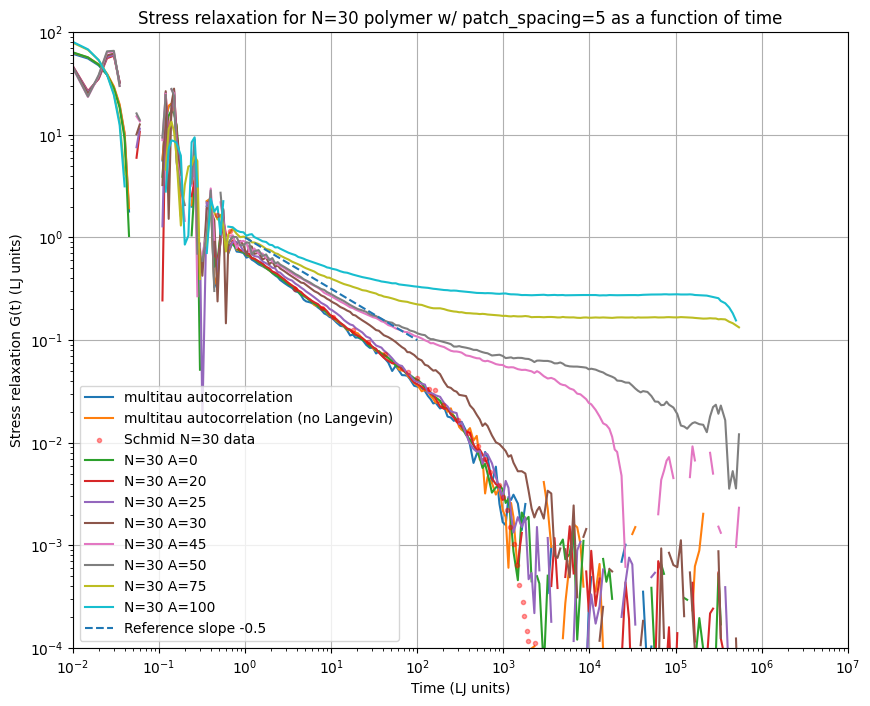

In [12]:
plt.figure(figsize=(10, 8))
plt.xscale('log')
plt.yscale('log')

plt.loglog(data_multitau['time'], G_t_multitau , label='multitau autocorrelation')
plt.loglog(data_multitau_no_langevin['time'], G_t_multitau_no_langevin , label='multitau autocorrelation (no Langevin)')
plt.scatter(data_schmid['time'], data_schmid['G_t'], color='red', marker='.', label='Schmid N=30 data', alpha=0.4, zorder=10)

for i, a in enumerate(A):
    plt.loglog(data[i]['time'], G_t[i], label=f'N=30 A={a}')

plt.loglog(np.logspace(0, 2), (np.logspace(0, 2))**-0.5, '--', label='Reference slope -0.5')
plt.xlabel('Time (LJ units)')
plt.ylabel('Stress relaxation G(t) (LJ units)')
plt.xlim([1e-2, 1e7])
plt.ylim([1e-4,1e2])
plt.grid()
plt.title('Stress relaxation for N=30 polymer w/ patch_spacing=5 as a function of time')
plt.legend()
plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\o'
<>:63: SyntaxWarning: invalid escape sequence '\o'
<>:51: SyntaxWarning: invalid escape sequence '\o'
<>:63: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2032848/3006739367.py:51: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(omega, omega**0.5, linestyle='--', label=f"$\omega$^{0.5}")
/tmp/ipykernel_2032848/3006739367.py:63: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(omega, omega**0.5, linestyle='--', label=f"$\omega$^{0.5}")


,omega_Gpp,Gpp,omega_Gp,Gp
0,0.000122,0.002947,0.000150,0.000127
1,0.000147,0.003728,0.000181,0.000188
2,0.000178,0.004715,0.000219,0.000283
3,0.000215,0.005429,0.000268,0.000426
4,0.000270,0.006551,0.000326,0.000631


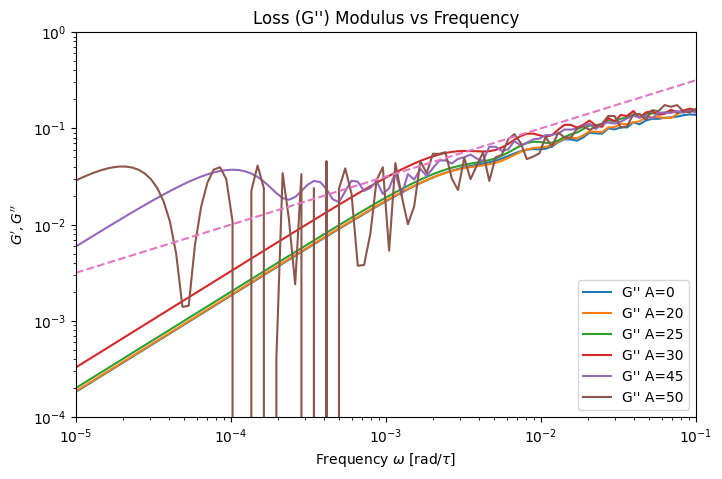

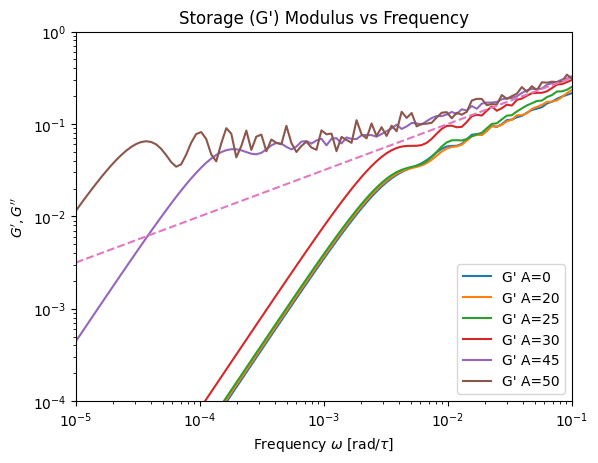

In [28]:
omega = np.logspace(-5, -1, 100)

prepped_G_t_multitau = G_t_multitau[(data_multitau['time'] > 1) & (data_multitau['time'] < 1000)].values
prepped_time = data_multitau['time'][(data_multitau['time'] > 1) & (data_multitau['time'] < 1000)].values

prepped_G_t_multitau_no_langevin = G_t_multitau_no_langevin[(data_multitau_no_langevin['time'] > 1) & (data_multitau_no_langevin['time'] < 1000)].values
prepped_time_no_langevin = data_multitau_no_langevin['time'][(data_multitau_no_langevin['time'] > 1) & (data_multitau_no_langevin['time'] < 1000)].values

# fourier transform of G_t_multitau

A = [0, 20, 25, 30, 45, 50]
Gp = []
Gpp = []
for i, a in enumerate(A):
    if a < 45:
        prepped_G_t_i = G_t[i][(data[i]['time'] > 1) & (data[i]['time'] < 1000)].values
        prepped_time = data[i]['time'][(data[i]['time'] > 1) & (data[i]['time'] < 1000)].values
    elif a < 50:
        prepped_G_t_i = G_t[i][(data[i]['time'] > 1) & (data[i]['time'] < 25000)].values
        prepped_time = data[i]['time'][(data[i]['time'] > 1) & (data[i]['time'] < 25000)].values
    else:
        prepped_G_t_i = G_t[i][(data[i]['time'] > 1) & (data[i]['time'] < 100000)].values
        prepped_time = data[i]['time'][(data[i]['time'] > 1) & (data[i]['time'] < 100000)].values
    _, Gp_i, Gpp_i = fourier_integral_moduli(prepped_time, prepped_G_t_i, omega)
    Gp.append(Gp_i)
    Gpp.append(Gpp_i)
# _, Gp, Gpp = fourier_integral_moduli(prepped_time, prepped_G_t_multitau, omega)
# _, Gp_no_langevin, Gpp_no_langevin = fourier_integral_moduli(prepped_time_no_langevin, prepped_G_t_multitau_no_langevin, omega)
# print(Gp[:10], Gpp[:10])
# _, Gp_no_patches, Gpp_no_patches = fourier_integral_moduli(prepped_time_no_patches, prepped_G_t_multitau_no_patches, omega)

file = "data/gpgpp_schmid_n30.csv"
data_schmid_gpgpp = pd.read_csv(file, skiprows=2, names=['omega_Gpp', 'Gpp', 'omega_Gp', 'Gp'])
display(data_schmid_gpgpp.head())

plt.figure(figsize=(8, 5))
plt.xscale('log')
plt.yscale('log')
# plt.loglog(data_schmid_gpgpp['omega_Gp'], data_schmid_gpgpp['Gp'], 'o', label="G' Schmid N=30", alpha=0.5)
# plt.loglog(data_schmid_gpgpp['omega_Gpp'], data_schmid_gpgpp['Gpp'], 'o', label="G'' Schmid N=30", alpha=0.5)

for i, a in enumerate(A):
    plt.loglog(omega, Gpp[i], label=f"G'' A={a}")
    plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
    plt.ylabel("$G', G''$")
    plt.xlim([1e-5, 1e-1])
    plt.ylim([1e-4, 1e0])
    plt.title("Loss (G'') Modulus vs Frequency")
    plt.grid()
    plt.legend()
plt.loglog(omega, omega**0.5, linestyle='--', label=f"$\omega$^{0.5}")
plt.show()

for i, a in enumerate(A):
    plt.loglog(omega, Gp[i], label=f"G' A={a}")
    plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
    plt.ylabel("$G', G''$")
    plt.xlim([1e-5, 1e-1])
    plt.ylim([1e-4, 1e0])
    plt.title("Storage (G') Modulus vs Frequency")
    plt.grid()
    plt.legend()
plt.loglog(omega, omega**0.5, linestyle='--', label=f"$\omega$^{0.5}")
plt.show()

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def process_autocorr(filename, V=30.450711**3, k_B=1.0, T =1.0):
    data_multitau = pd.read_csv(filename, delimiter=' ', skiprows=3, index_col=False, names=['time','px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
    G_t_multitau = V / (k_B * T) *  (data_multitau['pxy'] + data_multitau['pxz'] + data_multitau['pyz']) / 5.0 + \
                    V / (k_B * T) * (data_multitau['px_y'] + data_multitau['px_z'] + data_multitau['py_z']) / 30.0
    
    # replace negative values
    G_t_multitau = G_t_multitau.where(G_t_multitau >= 0, np.nan)

    return data_multitau["time"], G_t_multitau

def process_dyn_moduli(G_t_multitau, time, omega=np.logspace(-5, -1, 100), cutoff=1000):
    prepped_G_t_multitau = G_t_multitau[(time > 1) & (time < cutoff)].values
    prepped_time = time[(time > 1) & (time < cutoff)].values
    prepped_time = np.sort(prepped_time)
    # print(prepped_time)
    
    _, Gp, Gpp = fourier_integral_moduli(prepped_time, prepped_G_t_multitau, omega)

    return Gp, Gpp, omega

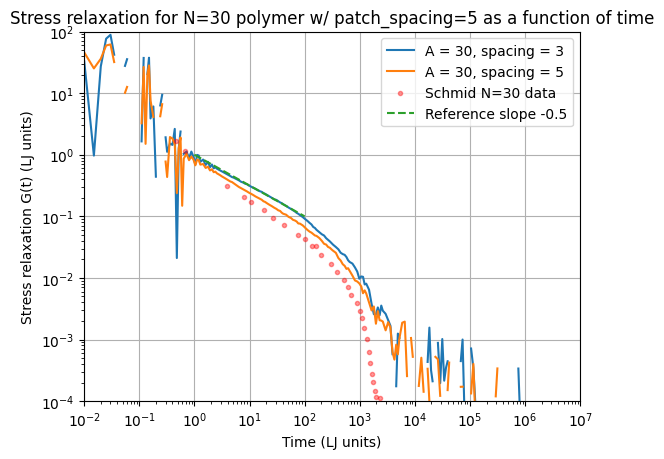

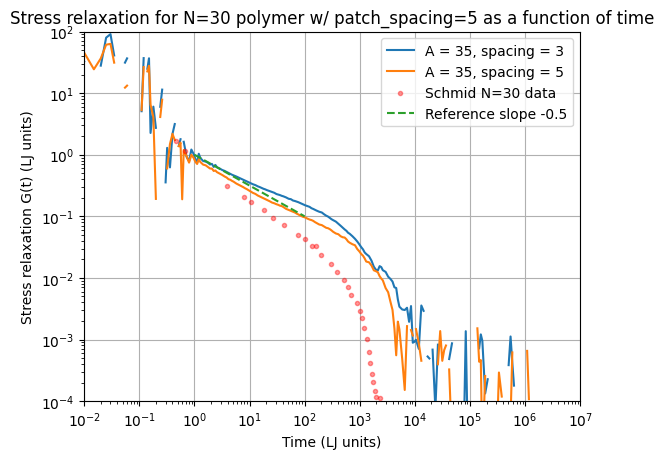

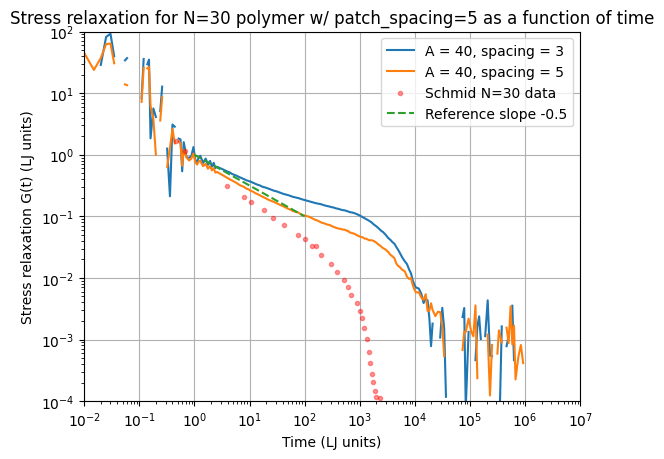

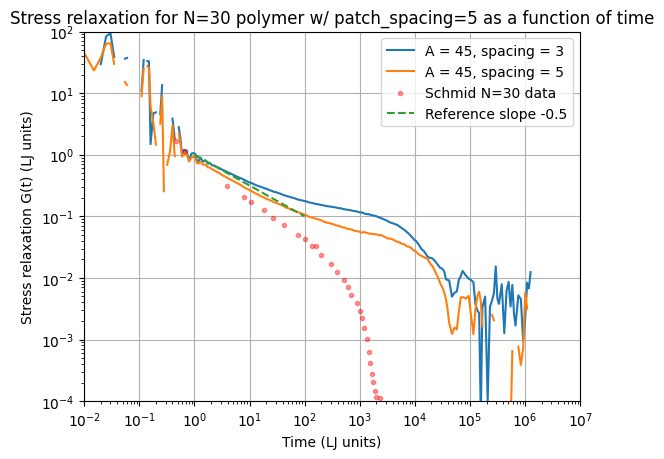

In [43]:
A = [30, 35, 40, 45]
spacings = [3, 5]

for a in A:
    for spacing in spacings:
        time, G_t = process_autocorr(f'data/autocorrelation/prodautocorr_chainlength_30_N_beads_24000_gaussA_{a}_spacing_{spacing}_r0_0.35_gaussB_10_seed_12345.dat')
        plt.loglog(time, G_t , label=f'A = {a}, spacing = {spacing}')

    # graph from Schmid paper with N=30 points extracted from their plot
    data_schmid = pd.read_csv("data/g_t_n30.csv", names=['G_t', 'time'])
    plt.scatter(data_schmid['time'], data_schmid['G_t'], color='red', marker='.', label='Schmid N=30 data', alpha=0.4, zorder=10)
    plt.loglog(np.logspace(0, 2), (np.logspace(0, 2))**-0.5, '--', label='Reference slope -0.5')
    plt.xlabel('Time (LJ units)')
    plt.ylabel('Stress relaxation G(t) (LJ units)')
    plt.xlim([1e-2, 1e7])
    plt.ylim([1e-4,1e2])
    plt.grid()
    plt.title('Stress relaxation for N=30 polymer w/ patch_spacing=5 as a function of time')
    plt.legend()
    plt.show()



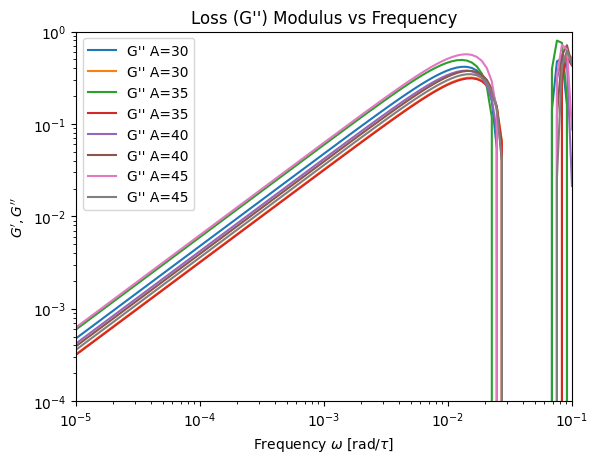

In [48]:
A = [30, 35, 40, 45]
spacings = [3, 5]

for a in A:
    for spacing in spacings:
        time, G_t = process_autocorr(f'data/autocorrelation/prodautocorr_chainlength_30_N_beads_24000_gaussA_{a}_spacing_{spacing}_r0_0.35_gaussB_10_seed_12345.dat')
        # print(time.values)
        Gp, Gpp, omega = process_dyn_moduli(time, G_t, cutoff=100)
        plt.loglog(omega, Gpp, label=f"G'' A={a}")
    plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
    plt.ylabel("$G', G''$")
    plt.xlim([1e-5, 1e-1])
    plt.ylim([1e-4, 1e0])
    plt.title("Loss (G'') Modulus vs Frequency")
    plt.grid()
    plt.legend()
    plt.show